In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Load dataset
dataset = pd.read_csv('Mall_Customers.csv')

# Select Annual Income and Spending Score
X = dataset.iloc[:, [3, 4]].values


# Preprocessing using Standard Scalar
from sklearn.preprocessing import StandardScaler
X = StandardScaler().fit_transform(X)

from sklearn.cluster import MeanShift, estimate_bandwidth

# Automatically estimate bandwidth
bandwidth = estimate_bandwidth(X, quantile=0.2, n_samples=len(X))

# -------------------------------
# MeanShift  Clustering
# -------------------------------
clus_Model = MeanShift(bandwidth=bandwidth, bin_seeding=True)
labels = clus_Model.fit_predict(X)

## Taking copy of the data set and adding Cluster Group as label
supervised = dataset.copy()
supervised['Cluster_group'] = labels

#supervised

C:\Anaconda\Lib\site-packages\seaborn\regression.py:598: UserWarning: legend_out is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)


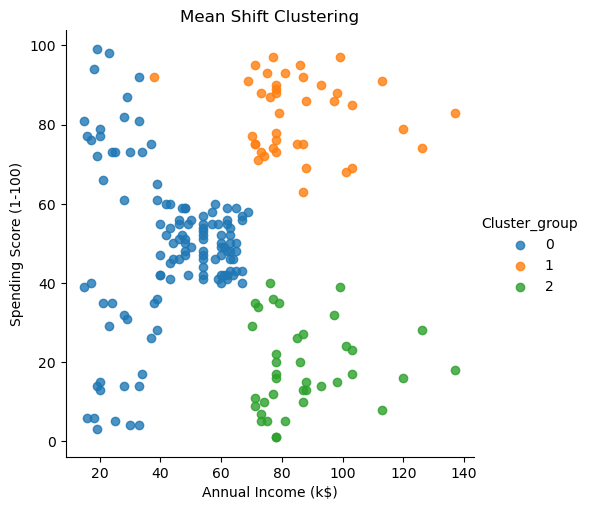

In [2]:
import seaborn as sns

facet = sns.lmplot(data=supervised,x=supervised.columns[3],y=supervised.columns[4],hue='Cluster_group',
                   fit_reg=False,legend=True,legend_out=True)
plt.title("Mean Shift Clustering")
plt.show()
